In [2]:
#Step 1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    MinMaxScaler,
    StandardScaler
)

plt.rcParams['figure.facecolor'] = '#F8FAFC'
plt.rcParams['axes.facecolor'] = '#FFFFFF'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

sns.set_style("whitegrid")

# Load Dataset

df = pd.read_csv('train.csv')

print("Shape:\n", df.shape)

print("\nInfo:\n")
print(df.info())

print("\nDescribe:\n")
print(df.describe())

# Numerical & Categorical Columns

num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print("\nNumerical Columns:\n")
print(num_cols)

print("\nCategorical Columns:\n")
print(cat_cols)

# Top Correlated Features

top_corr = (
    df.corr(numeric_only=True)['SalePrice'].abs()
    .sort_values(ascending=False)
    .head(10)
)
print("\nTop Correlated Features with SalePrice:\n")
print(top_corr)


Shape:
 (1460, 81)

Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-n

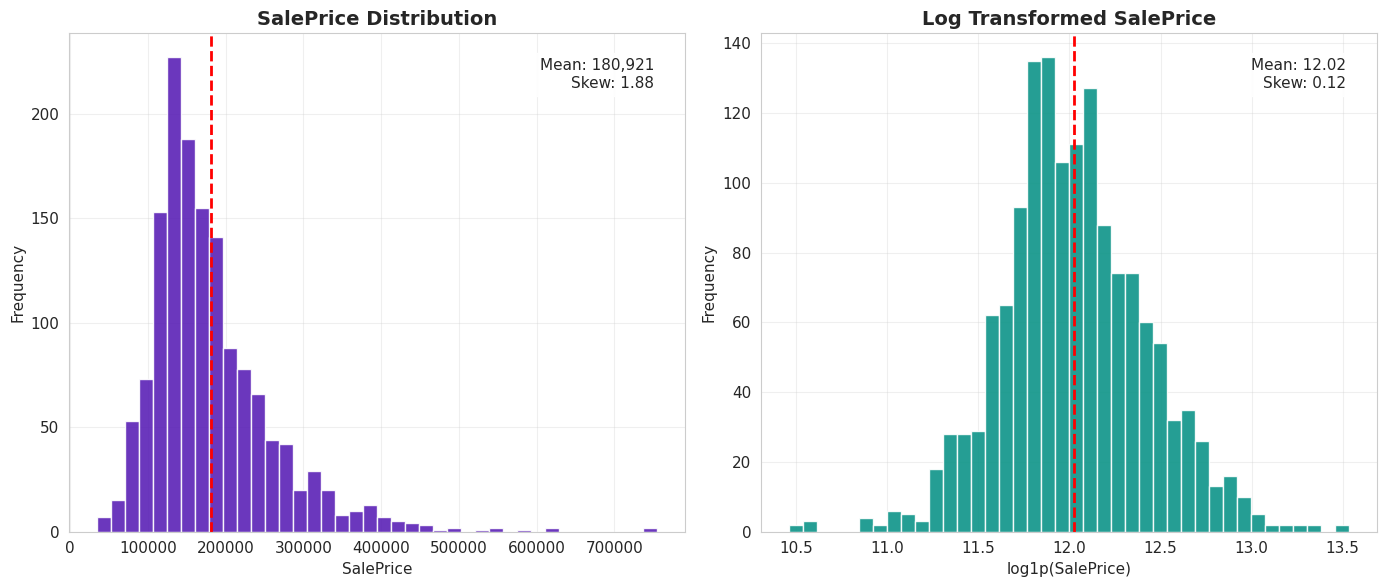

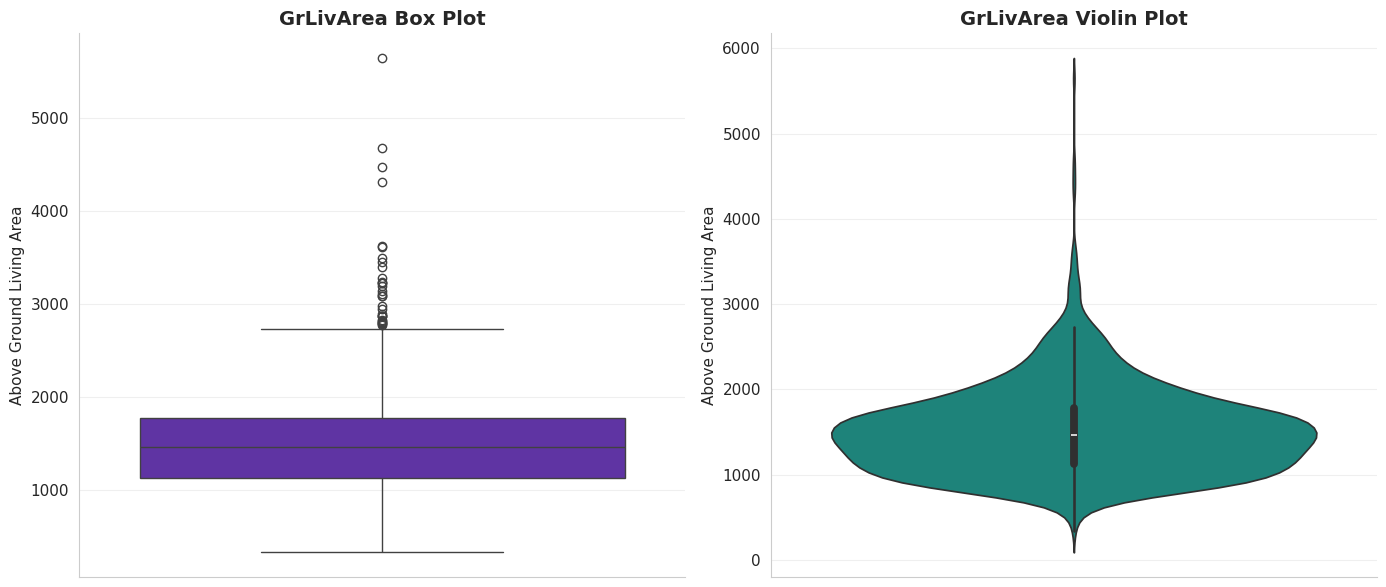

In [3]:
#Step 2
# Chart 1 — SalePrice Distribution
saleprice_log = np.log1p(df['SalePrice'])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Original SalePrice
axes[0].hist(
    df['SalePrice'],
    bins=40,
    color='#5B21B6',
    edgecolor='white',
    alpha=0.9
)

mean_price = df['SalePrice'].mean()
skew_price = df['SalePrice'].skew()

axes[0].axvline(mean_price, color='red', linestyle='--', linewidth=2)

axes[0].set_title('SalePrice Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

axes[0].text(
    0.95,
    0.95,
    f'Mean: {mean_price:,.0f}\nSkew: {skew_price:.2f}',
    transform=axes[0].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.9)
)

# Log Transformed SalePrice
axes[1].hist(
    saleprice_log,
    bins=40,
    color='#0D9488',
    edgecolor='white',
    alpha=0.9
)

mean_log = saleprice_log.mean()
skew_log = saleprice_log.skew()

axes[1].axvline(mean_log, color='red', linestyle='--', linewidth=2)

axes[1].set_title('Log Transformed SalePrice', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Frequency')

axes[1].text(
    0.95,
    0.95,
    f'Mean: {mean_log:.2f}\nSkew: {skew_log:.2f}',
    transform=axes[1].transAxes,
    ha='right',
    va='top',
    bbox=dict(facecolor='white', alpha=0.9)
)

plt.tight_layout()
plt.savefig('saleprice_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 2 — GrLivArea Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Box Plot
sns.boxplot(
    y=df['GrLivArea'],
    ax=axes[0],
    color='#5B21B6'
)

axes[0].set_title('GrLivArea Box Plot', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Above Ground Living Area')

# Violin Plot
sns.violinplot(
    y=df['GrLivArea'],
    ax=axes[1],
    color='#0D9488'
)

axes[1].set_title('GrLivArea Violin Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Above Ground Living Area')

for ax in axes:
    ax.set_facecolor('#FFFFFF')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('grlivarea_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

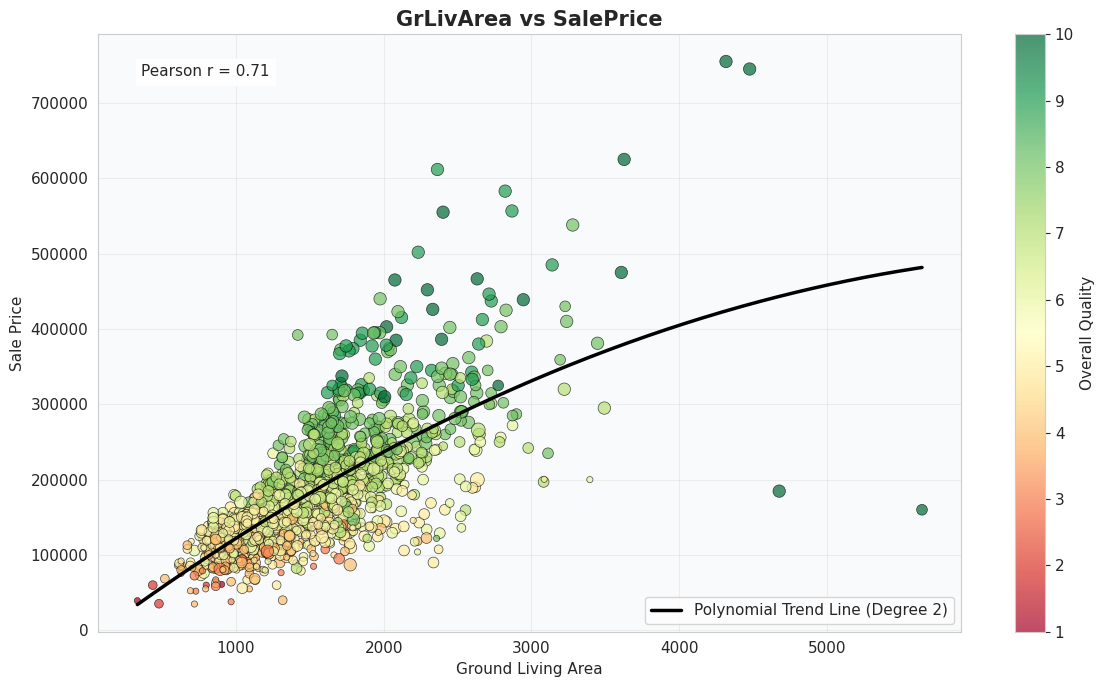

In [4]:
#Step 3
# Chart 3 — Multi-Variable Scatter Plot

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    df['GrLivArea'],
    df['SalePrice'],
    c=df['OverallQual'],
    cmap=plt.cm.RdYlGn,
    s=(df['GarageCars'].fillna(1) * 20) + 20,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)

# Polynomial Regression Line (Degree 2)
x = df['GrLivArea']
y = df['SalePrice']

coefficients = np.polyfit(x, y, 2)
poly = np.poly1d(coefficients)

x_line = np.linspace(x.min(), x.max(), 500)
y_line = poly(x_line)

ax.plot(
    x_line,
    y_line,
    color='black',
    linewidth=2.5,
    label='Polynomial Trend Line (Degree 2)'
)

# Pearson Correlation
corr = df['GrLivArea'].corr(df['SalePrice'])

ax.text(
    0.05,
    0.95,
    f'Pearson r = {corr:.2f}',
    transform=ax.transAxes,
    fontsize=11,
    va='top',
    bbox=dict(facecolor='white', alpha=0.9)
)

# Colorbar
cbar = plt.colorbar(scatter)
cbar.set_label('Overall Quality')

ax.set_title(
    'GrLivArea vs SalePrice',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Ground Living Area')
ax.set_ylabel('Sale Price')

ax.set_facecolor('#F9FAFB')
ax.legend()

plt.tight_layout()
plt.savefig('grlivarea_saleprice_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

### Multi-Variable Scatter Plot Explanation

This visualization encodes four variables simultaneously:

- **X-axis:** GrLivArea (above-ground living area)
- **Y-axis:** SalePrice
- **Color:** OverallQual using the RdYlGn colormap
- **Point Size:** GarageCars representing garage capacity

A polynomial regression line (degree 2) is added to capture the non-linear relationship between living area and sale price. The Pearson correlation coefficient is also annotated to measure the strength of the linear relationship between the two primary variables.

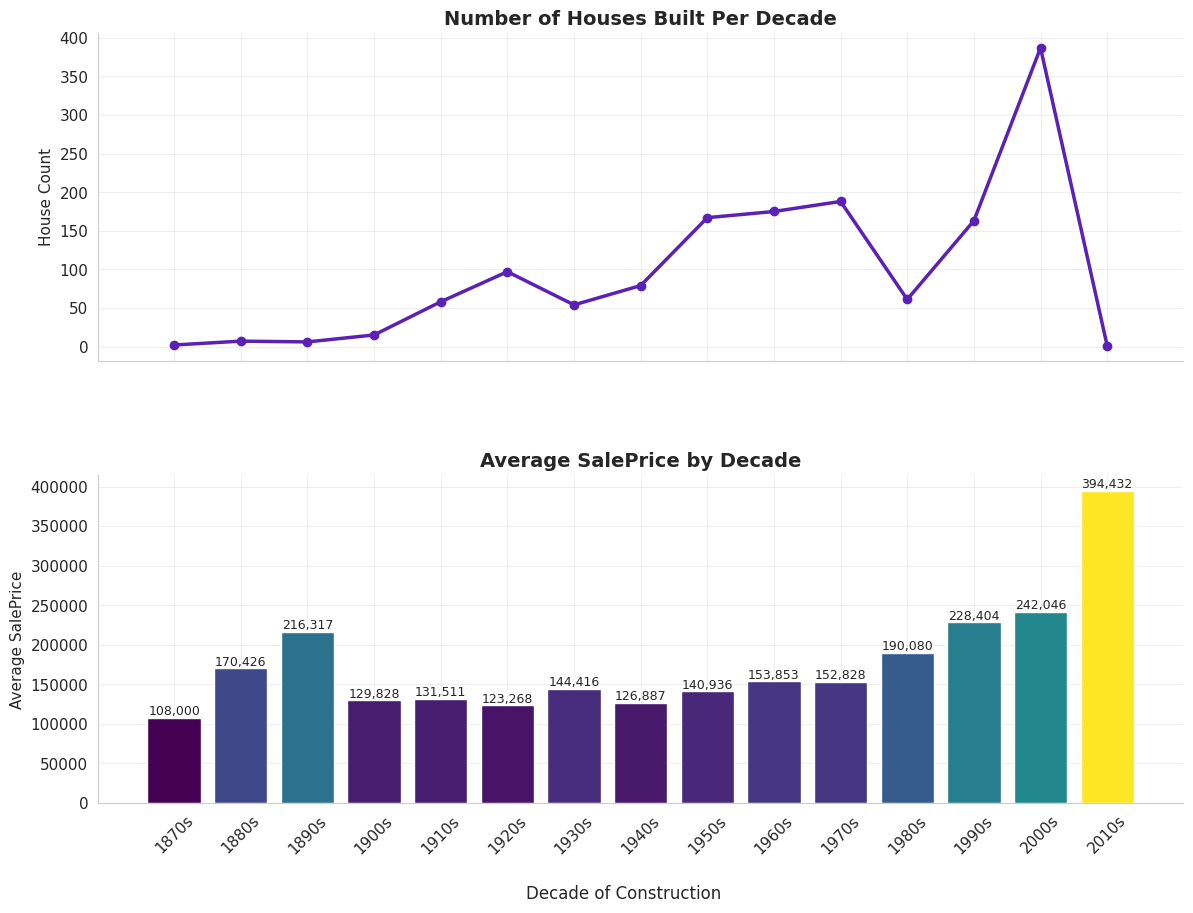

In [5]:
#Step 4
# Chart 4 — Time-Based Trend Analysis

# Create Decade Column
df['Decade'] = (df['YearBuilt'] // 10) * 10
df['DecadeLabel'] = df['Decade'].astype(str) + 's'

# Houses Sold Per Decade
decade_counts = df['DecadeLabel'].value_counts().sort_index()

# Average SalePrice Per Decade
avg_price_decade = (
    df.groupby('DecadeLabel')['SalePrice']
    .mean()
    .sort_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Top Plot — Houses Count by Decade

axes[0].plot(
    decade_counts.index,
    decade_counts.values,
    marker='o',
    linewidth=2.5,
    color='#5B21B6'
)

axes[0].set_title(
    'Number of Houses Built Per Decade',
    fontsize=14,
    fontweight='bold'
)

axes[0].set_ylabel('House Count')

# Bottom Plot — Average SalePrice by Decade

norm = plt.Normalize(
    avg_price_decade.min(),
    avg_price_decade.max()
)

colors = plt.cm.viridis(norm(avg_price_decade.values))

bars = axes[1].bar(
    avg_price_decade.index,
    avg_price_decade.values,
    color=colors
)

axes[1].set_title(
    'Average SalePrice by Decade',
    fontsize=14,
    fontweight='bold'
)

axes[1].set_ylabel('Average SalePrice')

# Value Labels
for bar in bars:
    height = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9
    )

# Shared X-axis Label
fig.supxlabel('Decade of Construction', fontsize=12)

# Styling
for ax in axes:
    ax.set_facecolor('#FFFFFF')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.35)

plt.savefig('w3_time_trend.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_499/1622457909.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


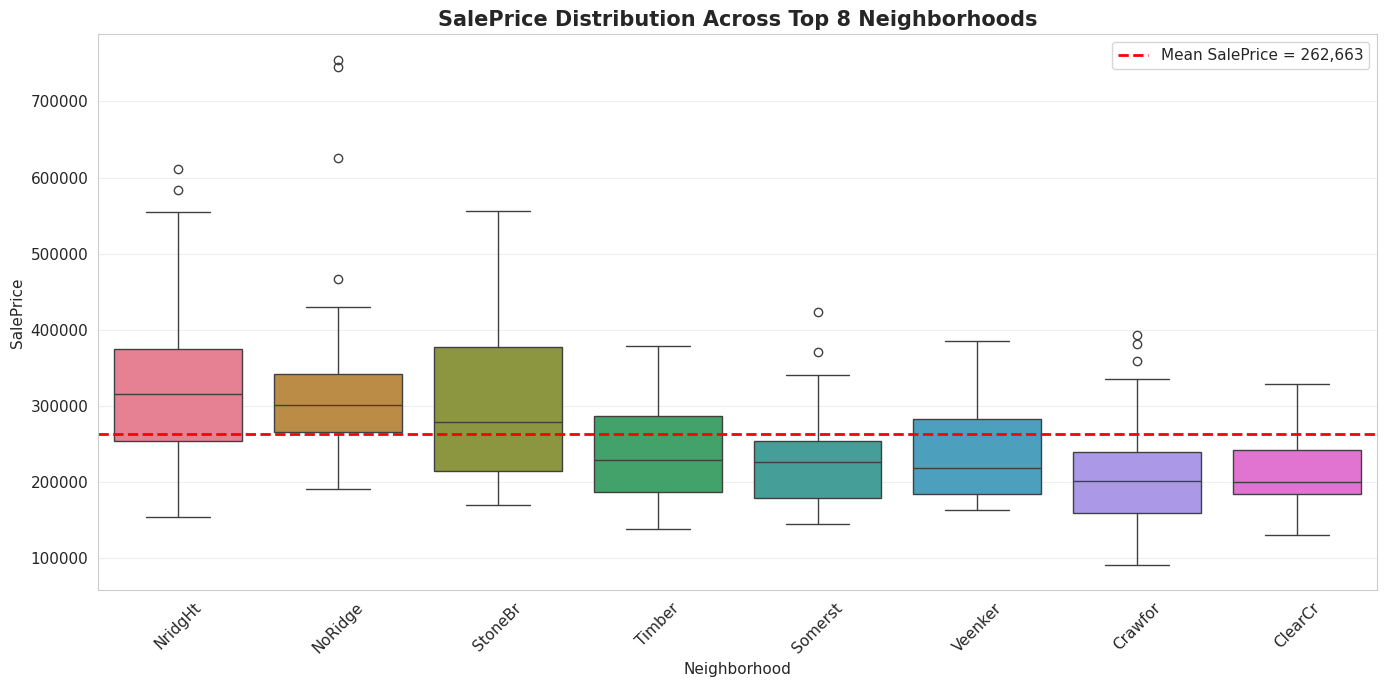

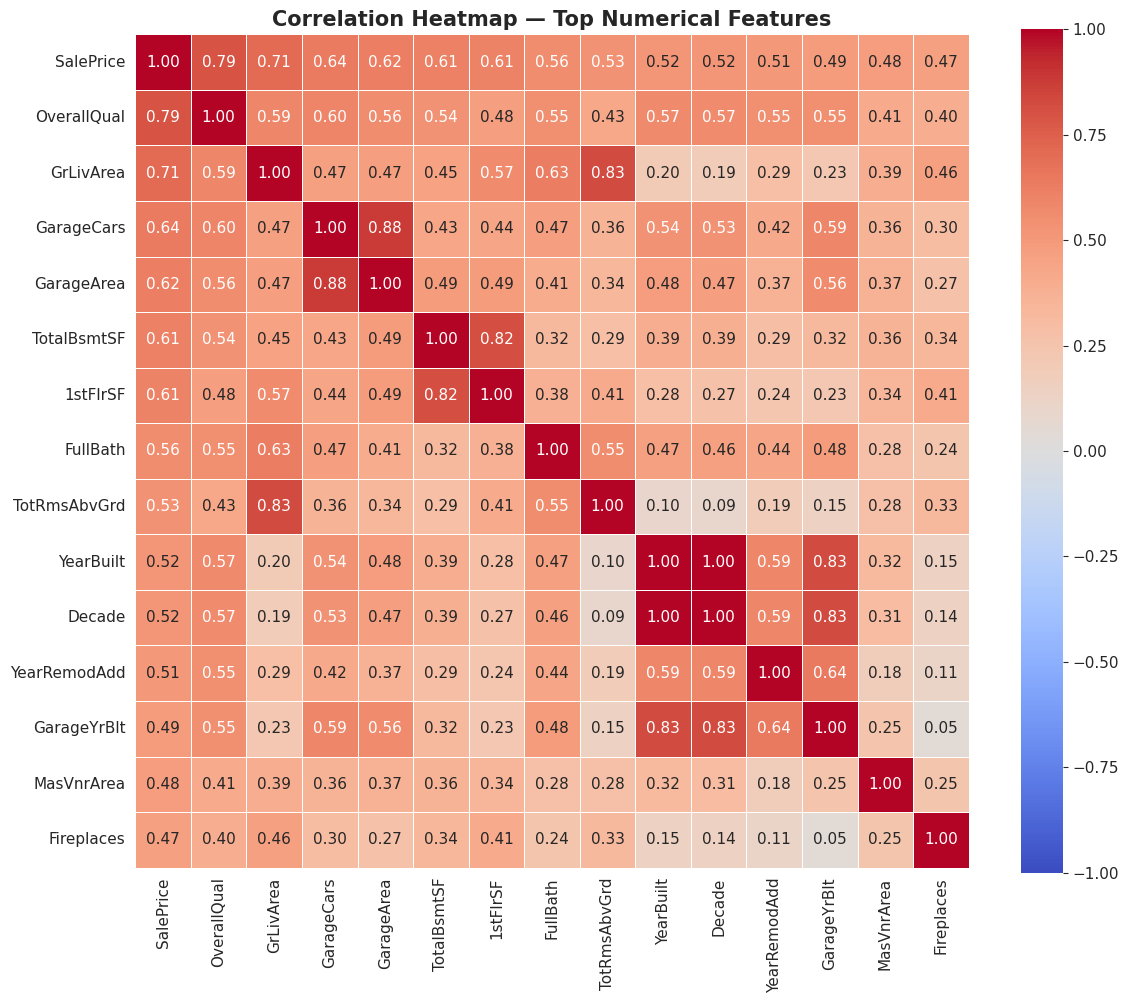

In [6]:
#Step 5
# Chart 5 — SalePrice Distribution by Neighborhood
top_neighborhoods = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .head(8)
    .index
)

filtered_df = df[df['Neighborhood'].isin(top_neighborhoods)]

mean_saleprice = filtered_df['SalePrice'].mean()

fig, ax = plt.subplots(figsize=(14, 7))

sns.boxplot(
    data=filtered_df,
    x='Neighborhood',
    y='SalePrice',
    order=top_neighborhoods,
    palette='husl',
    ax=ax
)

ax.axhline(
    mean_saleprice,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean SalePrice = {mean_saleprice:,.0f}'
)

ax.set_title(
    'SalePrice Distribution Across Top 8 Neighborhoods',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Neighborhood')
ax.set_ylabel('SalePrice')

ax.tick_params(axis='x', rotation=45)

ax.legend()

plt.tight_layout()
plt.savefig('w3_boxplot_neighborhood.png', dpi=300, bbox_inches='tight')
plt.show()

# Chart 6 — Correlation Heatmap
top_features = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

corr_matrix = df[top_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title(
    'Correlation Heatmap — Top Numerical Features',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.savefig('w3_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

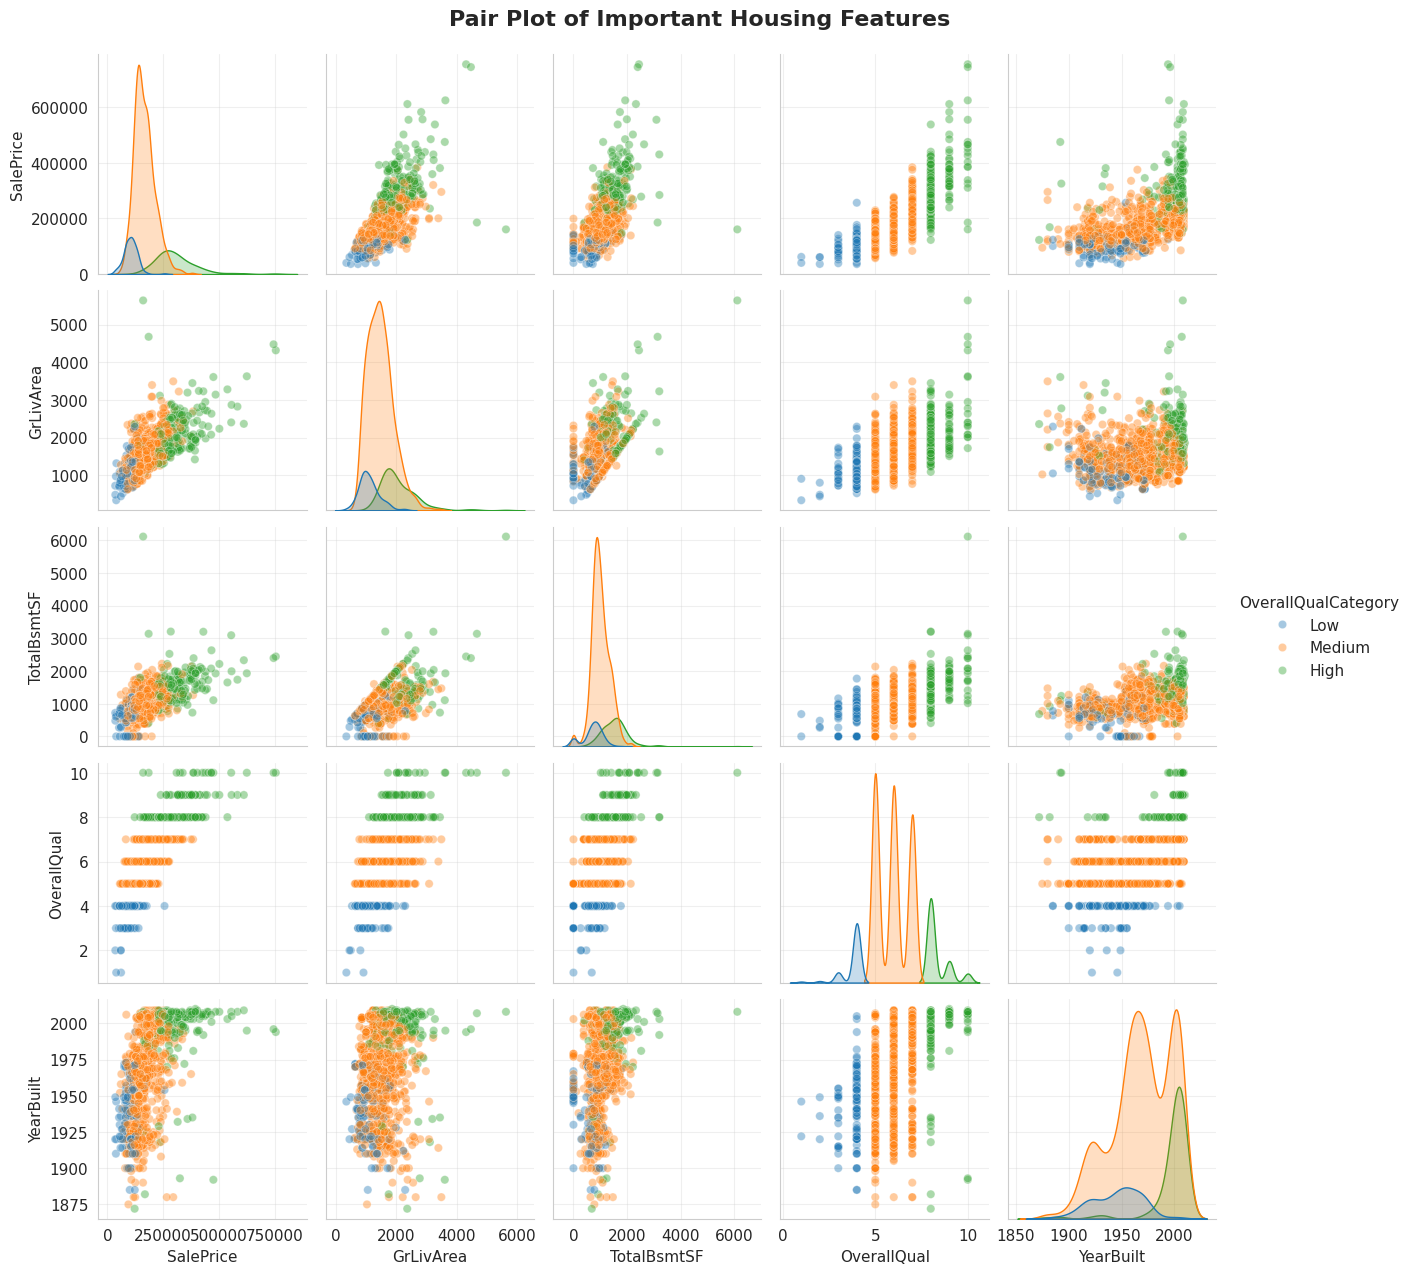

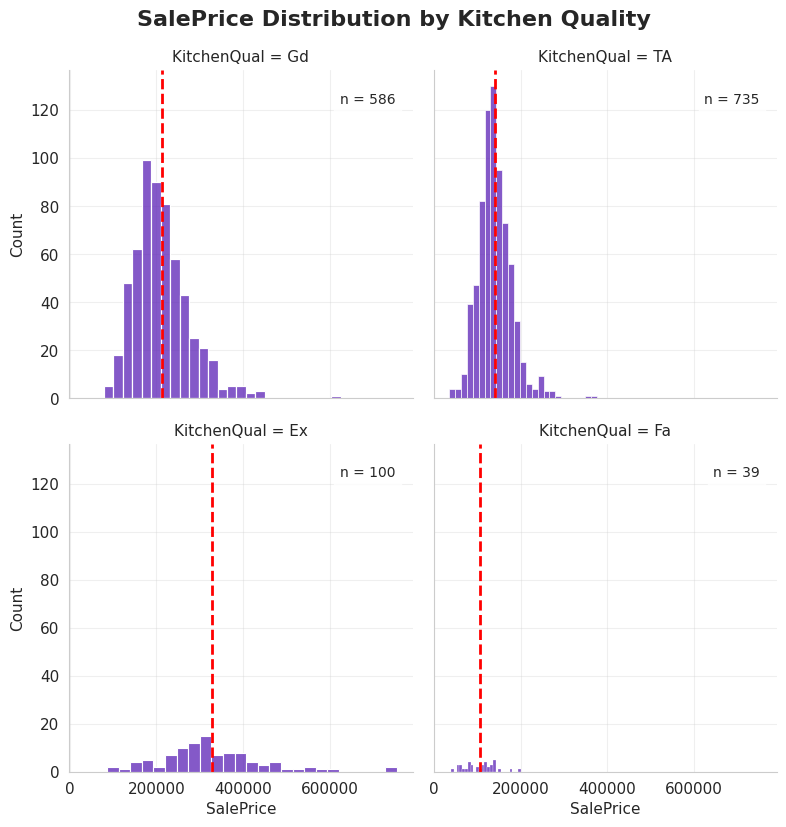

In [7]:
#Step 5
# Chart 7 — Pair Plot

pair_cols = [
    'SalePrice',
    'GrLivArea',
    'TotalBsmtSF',
    'OverallQual',
    'YearBuilt'
]

# Create OverallQual Category
df['OverallQualCategory'] = pd.cut(
    df['OverallQual'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Medium', 'High']
)

pairplot = sns.pairplot(
    df[pair_cols + ['OverallQualCategory']],
    hue='OverallQualCategory',
    diag_kind='kde',
    plot_kws=dict(alpha=0.4)
)

pairplot.fig.suptitle(
    'Pair Plot of Important Housing Features',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

pairplot.savefig('w3_pairplot.png', dpi=300, bbox_inches='tight')

plt.show()

# Chart 8 — FacetGrid
g = sns.FacetGrid(
    df,
    col='KitchenQual',
    col_wrap=2,
    height=4,
    sharex=True,
    sharey=True
)

g.map(
    sns.histplot,
    'SalePrice',
    bins=25,
    color='#5B21B6'
)

# Add Mean Line + Count Annotation
for ax, kitchen in zip(g.axes.flat, df['KitchenQual'].dropna().unique()):

    subset = df[df['KitchenQual'] == kitchen]

    mean_value = subset['SalePrice'].mean()
    count_value = subset.shape[0]

    ax.axvline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=2
    )

    ax.text(
        0.95,
        0.90,
        f'n = {count_value}',
        transform=ax.transAxes,
        ha='right',
        fontsize=10,
        bbox=dict(facecolor='white', alpha=0.8)
    )

g.fig.suptitle(
    'SalePrice Distribution by Kitchen Quality',
    fontsize=16,
    fontweight='bold',
    y=1.03
)

g.savefig('w3_facetgrid.png', dpi=300, bbox_inches='tight')

plt.show()

In [8]:
# Step 7

# Total property
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

df['TotalBaths'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

df['HasRemodeled'] = (df['YearBuilt'] != df['YearRemodAdd']).astype(int)

df['QualCond'] = df['OverallQual'] * df['OverallCond']

df['PricePerSF'] = np.where(
    df['TotalSF'] > 0,
    df['SalePrice'] / df['TotalSF'],
    0
)

df['IsNewHouse'] = (df['YearBuilt'] >= (df['YrSold'] - 5)).astype(int)

new_features = [
    'TotalSF',
    'TotalBaths',
    'HouseAge',
    'RemodelAge',
    'HasRemodeled',
    'QualCond',
    'PricePerSF',
    'IsNewHouse'
]

print("\nEngineered Features Description:\n")
print(df[new_features].describe())

print("\nFirst 10 Rows of Engineered Features:\n")
print(df[new_features].head(10))


Engineered Features Description:

            TotalSF   TotalBaths     HouseAge   RemodelAge  HasRemodeled  \
count   1460.000000  1460.000000  1460.000000  1460.000000   1460.000000   
mean    2567.048630     2.210616    36.547945    22.950000      0.476712   
std      821.714421     0.785399    30.250152    20.640653      0.499629   
min      334.000000     1.000000     0.000000    -1.000000      0.000000   
25%     2009.500000     2.000000     8.000000     4.000000      0.000000   
50%     2474.000000     2.000000    35.000000    14.000000      0.000000   
75%     3004.000000     2.500000    54.000000    41.000000      1.000000   
max    11752.000000     6.000000   136.000000    60.000000      1.000000   

          QualCond   PricePerSF   IsNewHouse  
count  1460.000000  1460.000000  1460.000000  
mean     33.864384    69.944000     0.212329  
std       9.219624    15.397065     0.409096  
min       1.000000    13.614704     0.000000  
25%      30.000000    60.461553     0.000000 


Top 20 Features Correlated with SalePrice:

SalePrice       1.000000
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
Decade          0.515824
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
IsNewHouse      0.433543
Name: SalePrice, dtype: float64

Bottom 10 Features Correlated with SalePrice:

Id              -0.021917
HasRemodeled    -0.021933
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
RemodelAge      -0.509079
HouseAge        -0.523350
Name: SalePrice, dtype: float64


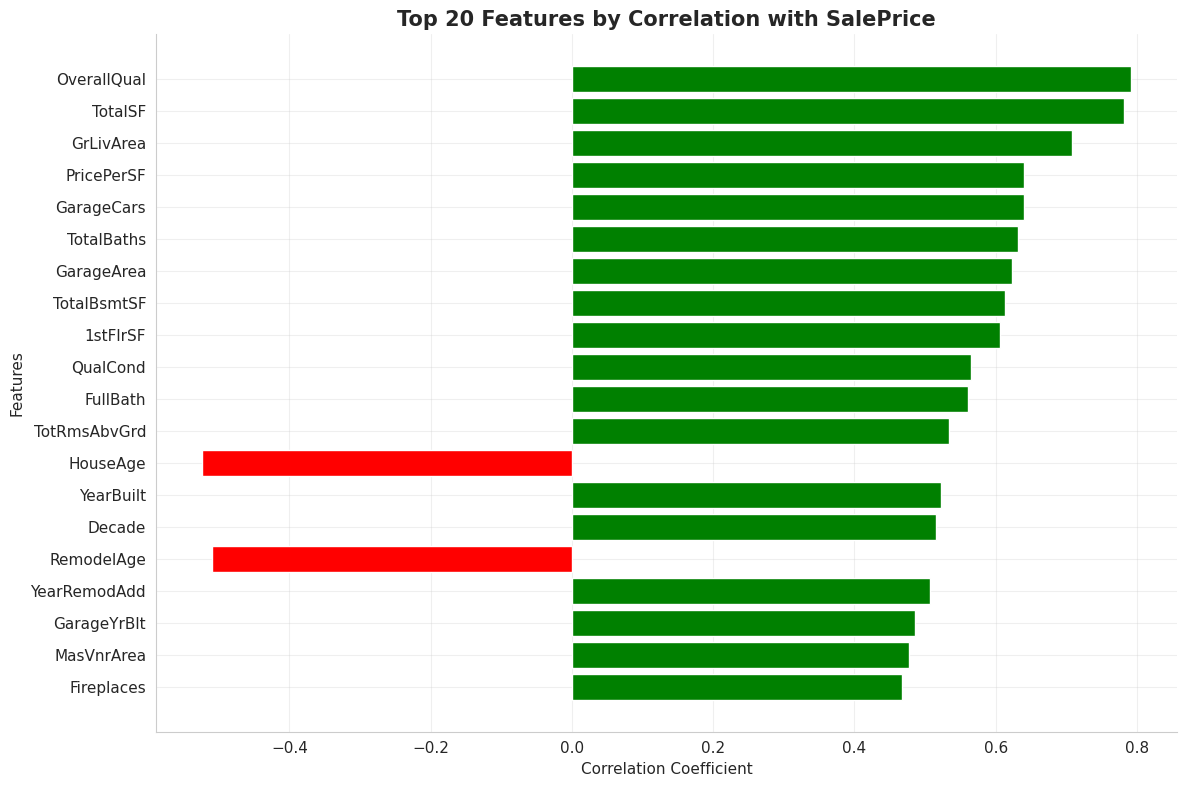

In [9]:
# Step 8 — Correlation Analysis

all_corr = (
    df.corr(numeric_only=True)['SalePrice']
    .sort_values(ascending=False)
)

# Top 20 Correlations
top_20_corr = all_corr.head(20)

# Bottom 10 Correlations
bottom_10_corr = all_corr.tail(10)

print("\nTop 20 Features Correlated with SalePrice:\n")
print(top_20_corr)

print("\nBottom 10 Features Correlated with SalePrice:\n")
print(bottom_10_corr)

# Horizontal Bar Chart

top_20_abs = (
    df.corr(numeric_only=True)['SalePrice']
    .drop('SalePrice')
    .abs()
    .sort_values(ascending=False)
    .head(20)
)

actual_corr = df.corr(numeric_only=True)['SalePrice'][top_20_abs.index]

colors = [
    'green' if val > 0 else 'red'
    for val in actual_corr
]

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    top_20_abs.index[::-1],
    actual_corr.values[::-1],
    color=colors[::-1]
)

ax.set_title(
    'Top 20 Features by Correlation with SalePrice',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Correlation Coefficient')
ax.set_ylabel('Features')

ax.set_facecolor('#FFFFFF')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig('w3_feature_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

### Correlation Analysis of Engineered Features

Among the 8 engineered features, the following appeared in the top 20 most correlated features with SalePrice:

- TotalSF → 0.782
- PricePerSF → 0.641
- TotalBaths → 0.632
- QualCond → 0.565
- IsNewHouse → 0.434

Additionally, HouseAge and RemodelAge showed strong negative correlations:

- HouseAge → -0.523
- RemodelAge → -0.509

This shows that engineered features can capture hidden relationships more effectively than raw features alone. Features such as total area, bathroom weighting, quality-condition interaction, and property age provide more meaningful information to machine learning models. The results demonstrate that feature engineering significantly improves the predictive strength of the dataset by transforming raw columns into analytically useful variables.

In [10]:
# Step 9
cat_cols = df.select_dtypes(include='object').columns

encoding_strategy = {}

ordinal_cols = [
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'GarageQual',
    'FireplaceQu'
]

print("\nCategorical Column Analysis:\n")

for col in cat_cols:

    print(f"\n{'='*60}")
    print(f"Column: {col}")

    unique_count = df[col].nunique()

    print(f"\nUnique Categories: {unique_count}")

    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))

    print("\nMean SalePrice by Category:")
    print(
        df.groupby(col)['SalePrice']
        .mean()
        .sort_values(ascending=False)
    )

    missing_ratio = df[col].isna().mean()

    dominant_ratio = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .iloc[0]
    )

    if missing_ratio > 0.5 or dominant_ratio > 0.95:
        strategy = 'drop'

    elif col in ordinal_cols:
        strategy = 'label_encode'

    elif unique_count <= 10:
        strategy = 'onehot_encode'

    else:
        strategy = 'frequency_encode'

    encoding_strategy[col] = strategy

print("\nEncoding Strategy:\n")
print(encoding_strategy)


Categorical Column Analysis:


Column: MSZoning

Unique Categories: 5

Value Counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Mean SalePrice by Category:
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64

Column: Street

Unique Categories: 2

Value Counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Mean SalePrice by Category:
Street
Pave    181130.538514
Grvl    130190.500000
Name: SalePrice, dtype: float64

Column: Alley

Unique Categories: 2

Value Counts:
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Mean SalePrice by Category:
Alley
Pave    168000.585366
Grvl    122219.080000
Name: SalePrice, dtype: float64

Column: LotShape

Unique Categories: 4

Value Counts:
LotShape
Reg    925
IR1    484
IR2     41
IR3     10
Name: count, dtype: int64

Mean SalePr

### Encoding Decision Table

| Column | Encoding Strategy | Reason |
|---|---|---|
| ExterQual | label_encode | Ordered quality scale (Po < Fa < TA < Gd < Ex) |
| KitchenQual | label_encode | Ordinal quality feature |
| BsmtQual | label_encode | Quality ranking exists |
| GarageQual | label_encode | Ordered quality categories |
| FireplaceQu | label_encode | Ordinal fireplace quality scale |
| Neighborhood | frequency_encode | Nominal feature with high cardinality (25 categories) |
| MSZoning | onehot_encode | Nominal categorical feature with small category count |
| Street | onehot_encode | Nominal binary category |
| Alley | drop | High percentage of missing values |
| LotShape | onehot_encode | Small nominal category count |
| LandContour | onehot_encode | Nominal feature with few categories |
| Utilities | drop | Single dominant category (>95%) |
| LotConfig | onehot_encode | Nominal feature with limited categories |
| LandSlope | onehot_encode | Small nominal category count |
| Condition1 | onehot_encode | Nominal categorical feature |
| Condition2 | onehot_encode | Nominal categorical feature |
| BldgType | onehot_encode | Few nominal categories |
| HouseStyle | onehot_encode | Nominal feature with manageable categories |
| RoofStyle | onehot_encode | Nominal feature with few categories |
| RoofMatl | onehot_encode | Small category count |
| Exterior1st | frequency_encode | High-cardinality nominal feature |
| Exterior2nd | frequency_encode | High-cardinality nominal feature |
| MasVnrType | onehot_encode | Nominal feature with few categories |
| Foundation | onehot_encode | Nominal feature |
| Heating | onehot_encode | Nominal feature |
| CentralAir | onehot_encode | Binary nominal feature |
| Electrical | onehot_encode | Small nominal category count |
| Functional | onehot_encode | Nominal categorical feature |
| GarageType | onehot_encode | Moderate category count |
| GarageFinish | onehot_encode | Nominal feature |
| PavedDrive | onehot_encode | Nominal categorical feature |
| SaleType | onehot_encode | Few nominal categories |
| SaleCondition | onehot_encode | Nominal categorical feature |


In [11]:
# Step 10
print("Shape Before Encoding:", df.shape)

# Drop Columns
drop_cols = [
    col for col, strategy in encoding_strategy.items()
    if strategy == 'drop'
]

df.drop(columns=drop_cols, inplace=True)

# Label Encoding for Quality Columns
quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0
}

label_cols = [
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'GarageQual',
    'FireplaceQu'
]

for col in label_cols:

    if col in df.columns:

        df[col] = (
            df[col]
            .fillna('NA')
            .map(quality_map)
        )

# Frequency Encoding
freq_cols = [
    col for col, strategy in encoding_strategy.items()
    if strategy == 'frequency_encode'
]

for col in freq_cols:

    freq_map = df[col].value_counts(normalize=True)

    df[col] = df[col].map(freq_map)

# One-Hot Encoding
onehot_cols = [
    col for col, strategy in encoding_strategy.items()
    if strategy == 'onehot_encode'
]

df = pd.get_dummies(
    df,
    columns=onehot_cols,
    drop_first=True
)
# Verify
print("\nRemaining Object Columns:\n")
print(df.select_dtypes(include='object').columns)

print("\nShape After Encoding:", df.shape)

Shape Before Encoding: (1460, 92)

Remaining Object Columns:

Index([], dtype='object')

Shape After Encoding: (1460, 163)



Scaling Comparison Table:

            Original Mean  Original Std  StandardScaler Mean  \
GrLivArea     1527.401541    524.432686        -1.307934e-16   
TotalSF       2583.476884    821.305316         1.429602e-16   
TotalBaths       2.222175      0.779502         1.231891e-16   

            StandardScaler Std  MinMaxScaler Mean  MinMaxScaler Std  \
GrLivArea             1.000428           0.224831          0.098800   
TotalSF               1.000428           0.197011          0.071931   
TotalBaths            1.000428           0.244435          0.155900   

            RobustScaler Mean  RobustScaler Std  
GrLivArea            0.084180          0.811501  
TotalSF              0.091210          0.837212  
TotalBaths           0.444349          1.559003  


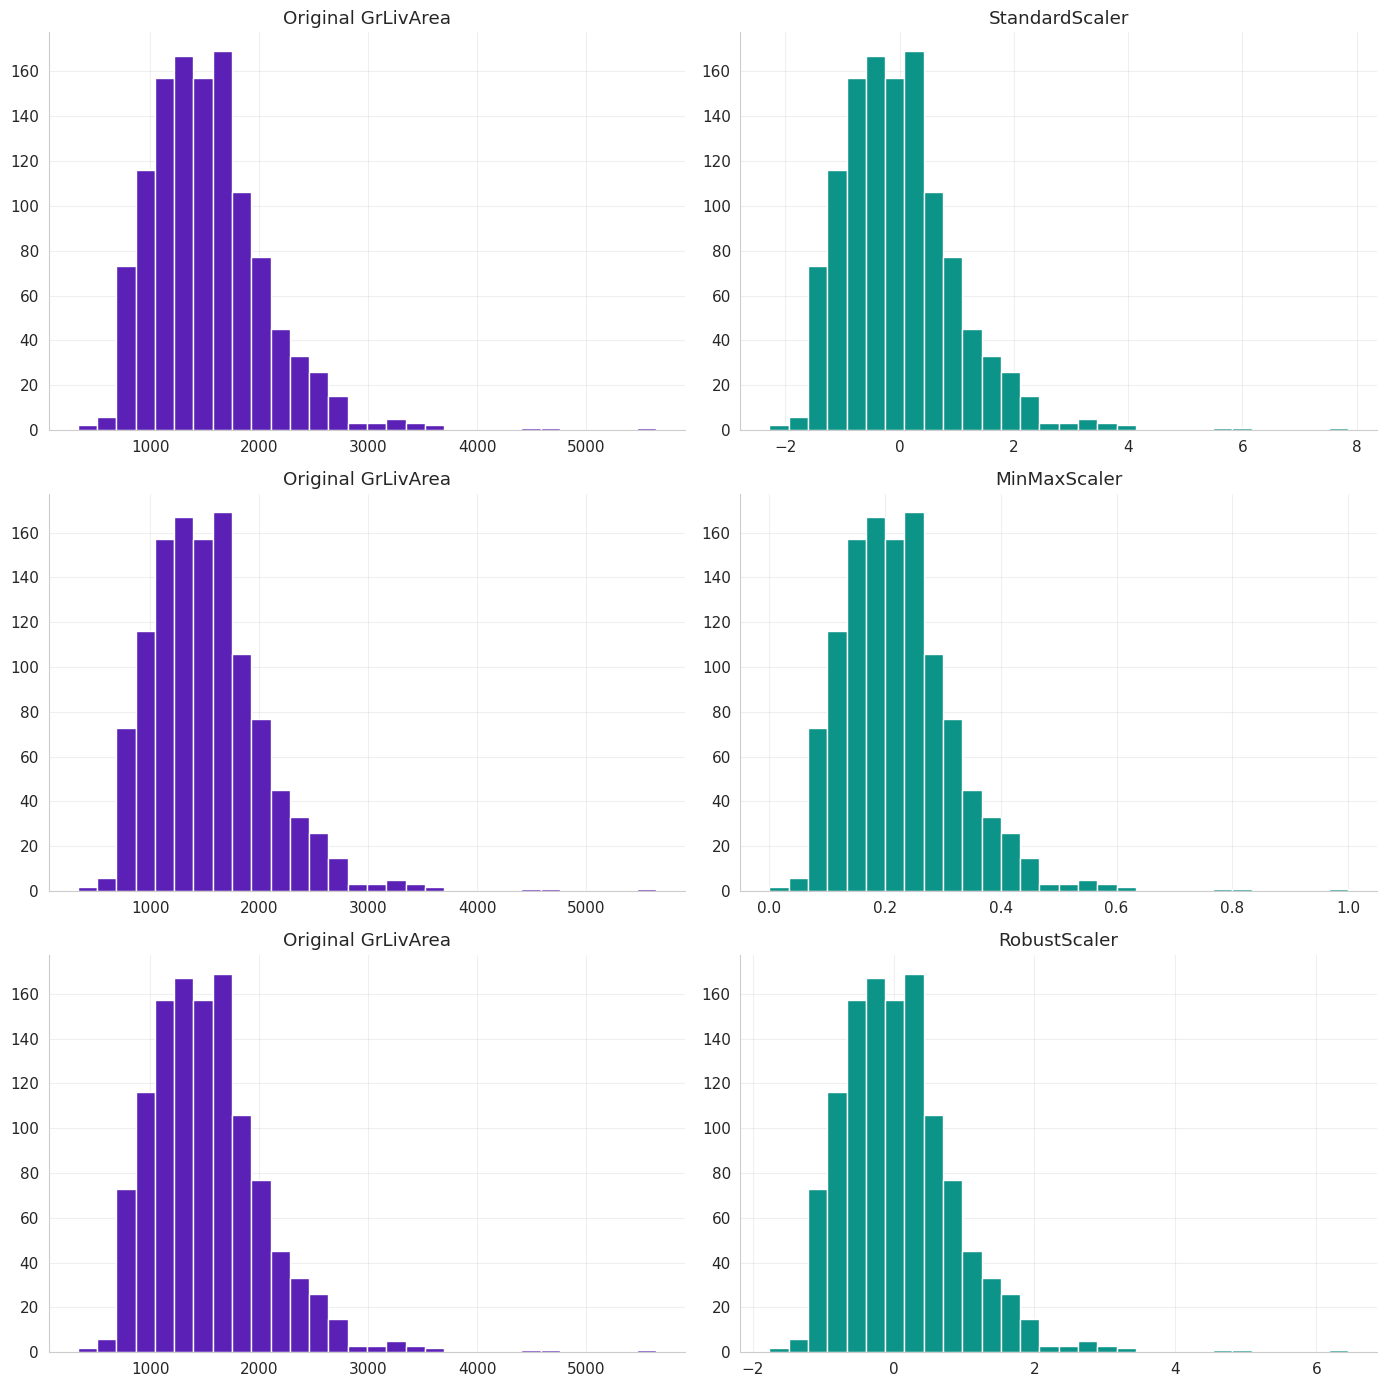

In [12]:
# Step 11
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

# Numerical Features Only
X = df.drop('SalePrice', axis=1)

X = X.select_dtypes(include=np.number)

y = df['SalePrice']

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

selected_features = [
    'GrLivArea',
    'TotalSF',
    'TotalBaths'
]

# StandardScaler
standard_scaler = StandardScaler()

X_train_std = pd.DataFrame(
    standard_scaler.fit_transform(X_train),
    columns=X_train.columns
)

# MinMaxScaler
minmax_scaler = MinMaxScaler()

X_train_mm = pd.DataFrame(
    minmax_scaler.fit_transform(X_train),
    columns=X_train.columns
)
# RobustScaler
robust_scaler = RobustScaler()

X_train_rb = pd.DataFrame(
    robust_scaler.fit_transform(X_train),
    columns=X_train.columns
)
# Comparison Table
comparison_table = pd.DataFrame({

    'Original Mean':
        X_train[selected_features].mean(),

    'Original Std':
        X_train[selected_features].std(),

    'StandardScaler Mean':
        X_train_std[selected_features].mean(),

    'StandardScaler Std':
        X_train_std[selected_features].std(),

    'MinMaxScaler Mean':
        X_train_mm[selected_features].mean(),

    'MinMaxScaler Std':
        X_train_mm[selected_features].std(),

    'RobustScaler Mean':
        X_train_rb[selected_features].mean(),

    'RobustScaler Std':
        X_train_rb[selected_features].std()
})

print("\nScaling Comparison Table:\n")
print(comparison_table)

# Histograms Before & After Scaling
fig, axes = plt.subplots(3, 2, figsize=(14, 14))

# StandardScaler
axes[0, 0].hist(X_train['GrLivArea'], bins=30, color='#5B21B6')
axes[0, 0].set_title('Original GrLivArea')

axes[0, 1].hist(X_train_std['GrLivArea'], bins=30, color='#0D9488')
axes[0, 1].set_title('StandardScaler')

# MinMaxScaler
axes[1, 0].hist(X_train['GrLivArea'], bins=30, color='#5B21B6')
axes[1, 0].set_title('Original GrLivArea')

axes[1, 1].hist(X_train_mm['GrLivArea'], bins=30, color='#0D9488')
axes[1, 1].set_title('MinMaxScaler')

# RobustScaler
axes[2, 0].hist(X_train['GrLivArea'], bins=30, color='#5B21B6')
axes[2, 0].set_title('Original GrLivArea')

axes[2, 1].hist(X_train_rb['GrLivArea'], bins=30, color='#0D9488')
axes[2, 1].set_title('RobustScaler')

for ax in axes.flat:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    'w3_scaling_comparison.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

### Best Scaling Method for Linear Regression

For Week 4 Linear Regression, StandardScaler would be the preferred choice because linear regression performs best when numerical features are centered around a mean of 0 with a standard deviation of 1. Standardization ensures that features with large numeric ranges do not dominate the model coefficients.

Compared to MinMaxScaler, StandardScaler is less sensitive to extreme values and preserves the underlying distribution more effectively. RobustScaler is useful when strong outliers are present, but for this housing dataset StandardScaler provides a balanced and commonly accepted preprocessing approach for regression models.


Skewness Analysis Table:

          Feature   Skewness   Severity
42        MiscVal  24.476794  Very High
41       PoolArea  14.828374  Very High
3         LotArea  12.207688  Very High
39      3SsnPorch  10.304342  Very High
20   LowQualFinSF   9.011341  Very High
27   KitchenAbvGr   4.488397  Very High
15     BsmtFinSF2   4.255261  Very High
40    ScreenPorch   4.122214  Very High
23   BsmtHalfBath   4.103403  Very High
35     GarageQual  -3.228583  Very High
38  EnclosedPorch   3.089872  Very High
11     MasVnrArea   2.669084  Very High
37    OpenPorchSF   2.364342  Very High
2     LotFrontage   2.163569  Very High
45      SalePrice   1.882876       High
48        TotalSF   1.776700       High
14     BsmtFinSF1   1.685503       High
36     WoodDeckSF   1.541376       High
17    TotalBsmtSF   1.524255       High
55     IsNewHouse   1.408303       High
1      MSSubClass   1.407657       High
18       1stFlrSF   1.376757       High
21      GrLivArea   1.366560       High
13       Bsmt

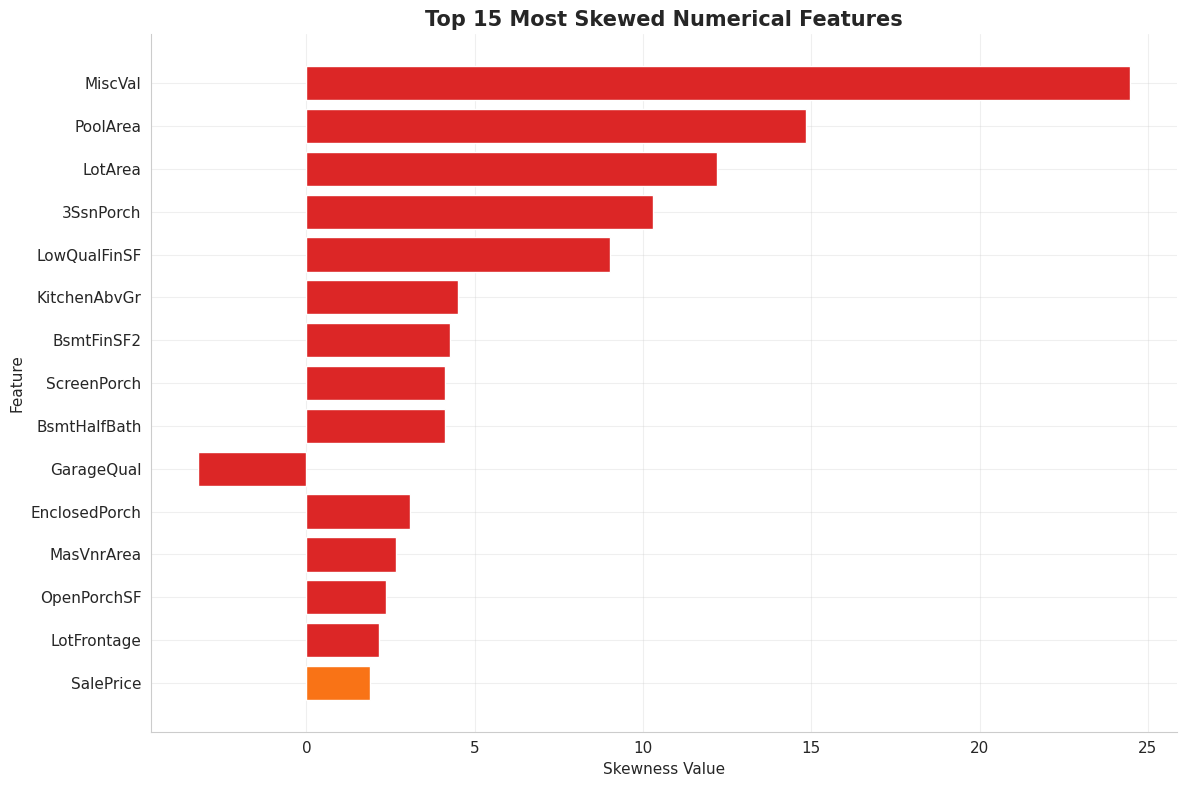

In [13]:
# Step 12
numeric_df = df.select_dtypes(include='number')

skew_values = numeric_df.skew()

skew_df = pd.DataFrame({
    'Feature': skew_values.index,
    'Skewness': skew_values.values
})

skew_df['AbsSkew'] = skew_df['Skewness'].abs()

# Severity Classification
def classify_skew(skew):

    skew = abs(skew)

    if skew < 0.5:
        return 'Normal'

    elif skew < 1:
        return 'Moderate'

    elif skew < 2:
        return 'High'

    else:
        return 'Very High'

skew_df['Severity'] = skew_df['Skewness'].apply(classify_skew)

# Sort by Absolute Skewness
skew_df = skew_df.sort_values(
    by='AbsSkew',
    ascending=False
)

print("\nSkewness Analysis Table:\n")
print(
    skew_df[['Feature', 'Skewness', 'Severity']]
)
high_skew_count = (skew_df['AbsSkew'] > 1).sum()

total_numeric = len(skew_df)

high_skew_percentage = (
    high_skew_count / total_numeric
) * 100

print(f"\nFeatures with |skew| > 1: {high_skew_count}")

print(
    f"Percentage Highly Skewed: "
    f"{high_skew_percentage:.2f}%"
)

# Horizontal Bar Chart — Top 15 Most Skewed Features
top_skew = skew_df.head(15)

severity_colors = {
    'Normal': '#22C55E',
    'Moderate': '#EAB308',
    'High': '#F97316',
    'Very High': '#DC2626'
}

colors = [
    severity_colors[val]
    for val in top_skew['Severity']
]

fig, ax = plt.subplots(figsize=(12, 8))

ax.barh(
    top_skew['Feature'][::-1],
    top_skew['Skewness'][::-1],
    color=colors[::-1]
)

ax.set_title(
    'Top 15 Most Skewed Numerical Features',
    fontsize=15,
    fontweight='bold'
)

ax.set_xlabel('Skewness Value')
ax.set_ylabel('Feature')

ax.set_facecolor('#FFFFFF')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()

plt.savefig(
    'w3_skewness_analysis.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()


SalePrice Skewness Comparison:

Original: 1.883
log1p: 0.121
sqrt: 0.943
Box-Cox: -0.009
Box-Cox Lambda: -0.077


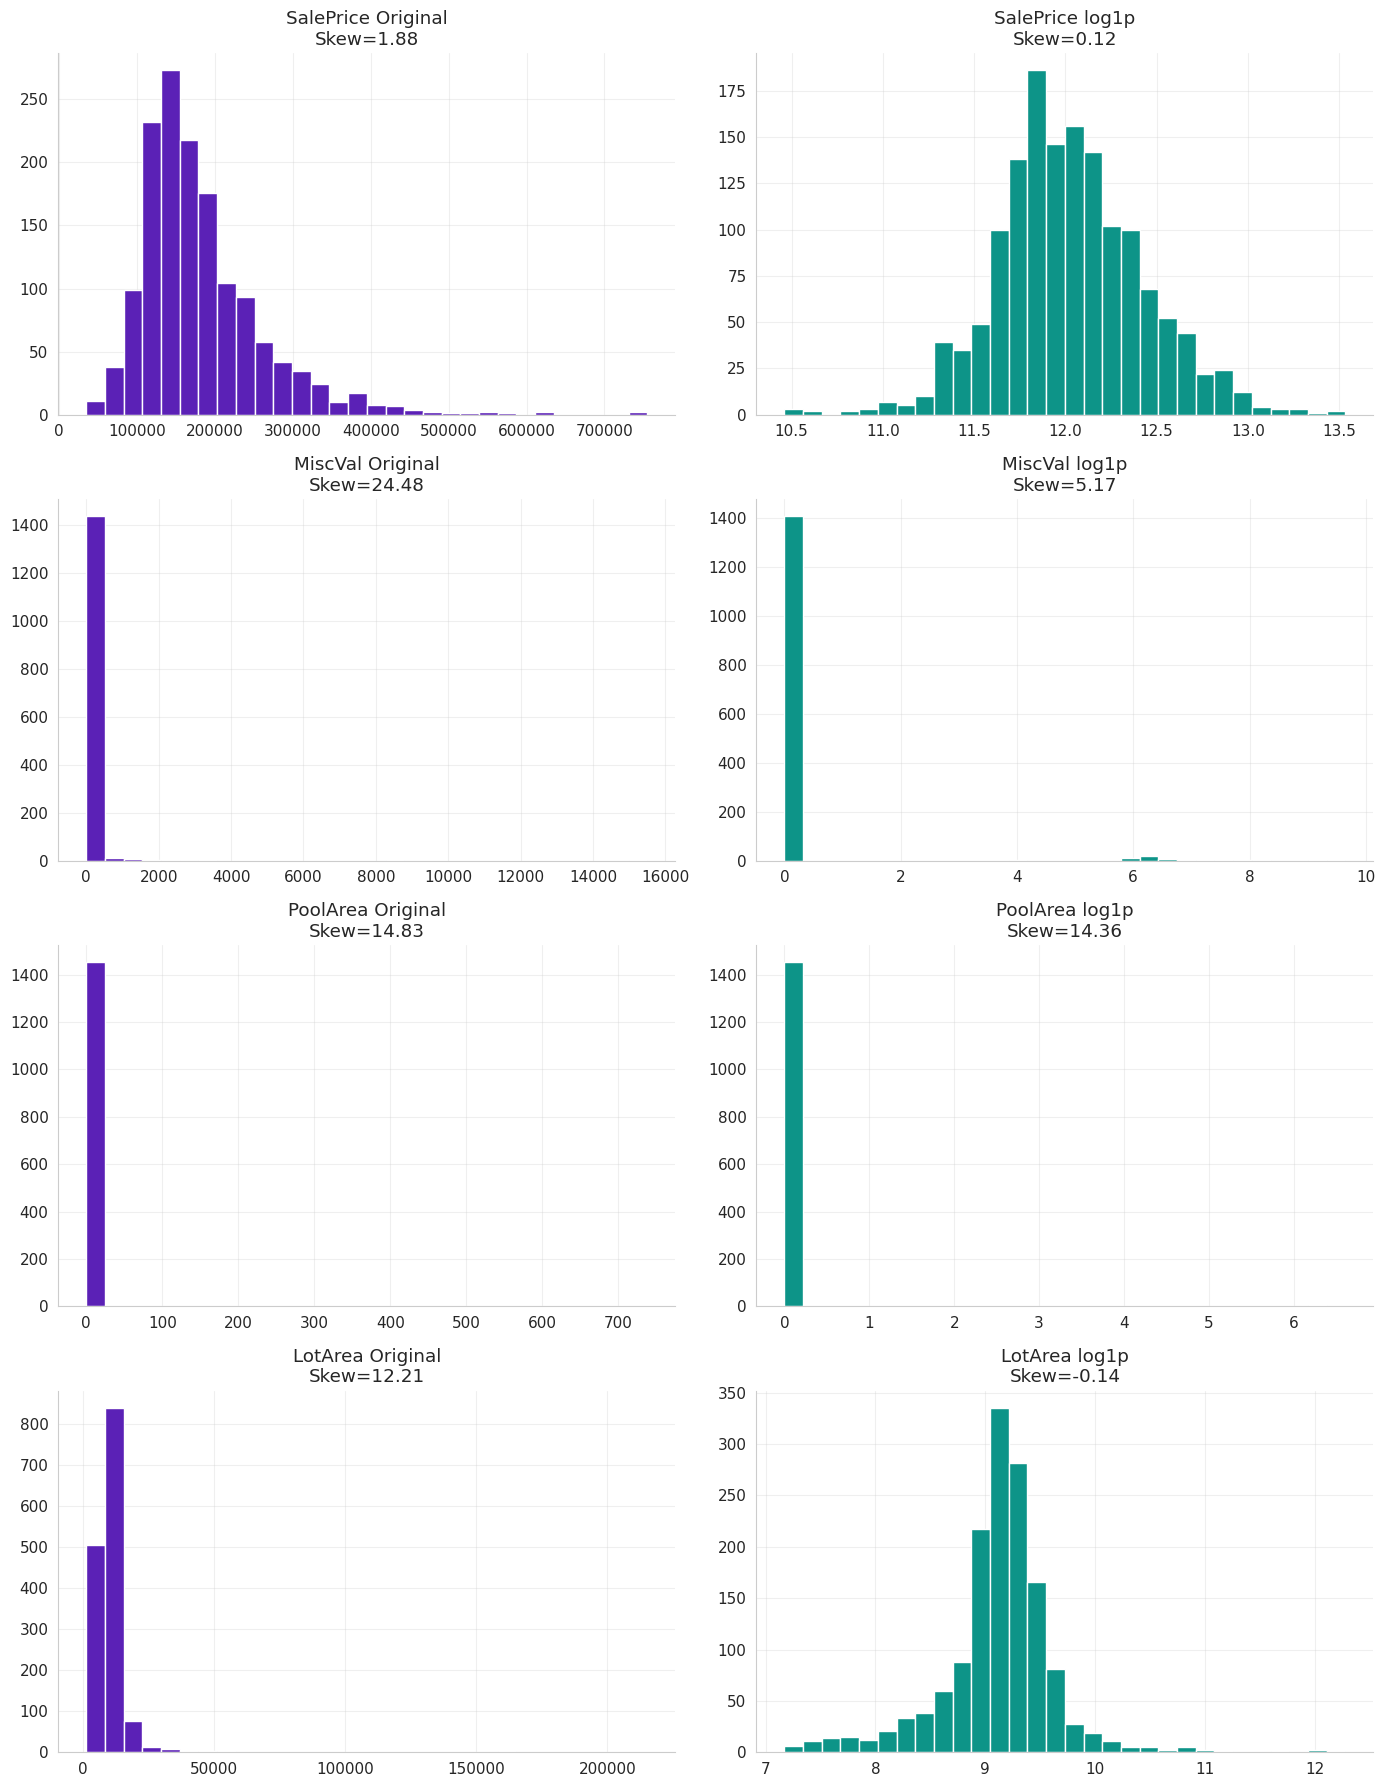

In [14]:
# Step 13

from scipy.stats import boxcox

high_skew_features = skew_df[
    (skew_df['AbsSkew'] > 0.75) &
    (skew_df['Feature'] != 'SalePrice')
]['Feature']

for col in high_skew_features:

    if (df[col] >= 0).all():

        df[col] = np.log1p(df[col])

# SalePrice Transformations
saleprice_original = df['SalePrice']

saleprice_log = np.log1p(saleprice_original)

saleprice_sqrt = np.sqrt(saleprice_original)

saleprice_boxcox, lambda_value = boxcox(saleprice_original)

# Compare Skewness
print("\nSalePrice Skewness Comparison:\n")

print(f"Original: {saleprice_original.skew():.3f}")

print(f"log1p: {saleprice_log.skew():.3f}")

print(f"sqrt: {saleprice_sqrt.skew():.3f}")

print(f"Box-Cox: {pd.Series(saleprice_boxcox).skew():.3f}")

print(f"Box-Cox Lambda: {lambda_value:.3f}")

# Select Additional Highly Skewed Features
extra_features = list(
    high_skew_features.head(3)
)

fig, axes = plt.subplots(4, 2, figsize=(14, 18))

# SalePrice — Original vs Best Transform
axes[0, 0].hist(
    saleprice_original,
    bins=30,
    color='#5B21B6',
    edgecolor='white'
)

axes[0, 0].set_title(
    f'SalePrice Original\nSkew={saleprice_original.skew():.2f}'
)

axes[0, 1].hist(
    saleprice_log,
    bins=30,
    color='#0D9488',
    edgecolor='white'
)

axes[0, 1].set_title(
    f'SalePrice log1p\nSkew={saleprice_log.skew():.2f}'
)

# Additional Features
for i, feature in enumerate(extra_features, start=1):

    original_data = numeric_df[feature]

    transformed_data = np.log1p(original_data)

    axes[i, 0].hist(
        original_data,
        bins=30,
        color='#5B21B6',
        edgecolor='white'
    )

    axes[i, 0].set_title(
        f'{feature} Original\nSkew={original_data.skew():.2f}'
    )

    axes[i, 1].hist(
        transformed_data,
        bins=30,
        color='#0D9488',
        edgecolor='white'
    )

    axes[i, 1].set_title(
        f'{feature} log1p\nSkew={transformed_data.skew():.2f}'
    )
# Styling
for ax in axes.flat:

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    'w3_skewness_transformations.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

# Final SalePrice Transformation
df['SalePrice_transformed'] = saleprice_log

### Skewness Transformation Analysis

Skewness analysis showed that several numerical features had highly right-skewed distributions, meaning extreme values stretched the distribution tail toward larger values.

Features with |skew| > 0.75 were transformed using log1p() because logarithmic transformation reduces the influence of extreme values while preserving feature relationships.

For SalePrice, three transformations were compared:

- log1p()
- sqrt()
- Box-Cox

Among these, the log1p() transformation produced the most balanced and near-normal distribution while handling zero values safely and reducing skewness significantly. Therefore, SalePrice_transformed was created using np.log1p(SalePrice) for future machine learning modelling.

In [15]:
# Step 14
from sklearn.feature_selection import VarianceThreshold

print("Shape Before Feature Selection:", df.shape)

# Correlation with target
corr_target = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False)

# Top 30 features excluding target
top_30_features = corr_target.index[1:31].tolist()

print("\nTop 30 Features by Absolute Correlation:\n")
print(corr_target.head(31))

# Build dataframe with top features
df_top = df[top_30_features + ['SalePrice']].copy()

# Variance Threshold
X_var = df_top.drop('SalePrice', axis=1)

vt = VarianceThreshold(threshold=0.01)
X_var_selected = vt.fit_transform(X_var)

selected_after_variance = X_var.columns[vt.get_support()].tolist()

print("\nFeatures Remaining After Variance Threshold:")
print(selected_after_variance)

# Remove multicollinearity
corr_matrix = df[selected_after_variance].corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = []

for col in upper.columns:
    high_corr = upper[col][upper[col] > 0.95]

    for row in high_corr.index:

        corr_col = abs(df[col].corr(df['SalePrice']))
        corr_row = abs(df[row].corr(df['SalePrice']))

        if corr_col < corr_row:
            if col not in to_drop:
                to_drop.append(col)
        else:
            if row not in to_drop:
                to_drop.append(row)

final_features = [col for col in selected_after_variance if col not in to_drop]

print("\nDropped Due To Multicollinearity:")
print(to_drop)

print("\nFinal Selected Features:\n")

final_feature_info = pd.DataFrame({
    'Feature': final_features,
    'CorrelationWithSalePrice': [
        df[col].corr(df['SalePrice']) for col in final_features
    ],
    'DataType': [
        df[col].dtype for col in final_features
    ]
}).sort_values(by='CorrelationWithSalePrice', key=abs, ascending=False)

print(final_feature_info)

# Final stats
initial_feature_count = df.shape[1] - 1
final_feature_count = len(final_features)

eliminated = initial_feature_count - final_feature_count
eliminated_percent = (eliminated / initial_feature_count) * 100

print("\nFinal Feature Count:", final_feature_count)
print("Original Feature Count:", initial_feature_count)
print("Eliminated Features:", eliminated)
print(f"Percentage Eliminated: {eliminated_percent:.2f}%")

Shape Before Feature Selection: (1460, 164)

Top 30 Features by Absolute Correlation:

SalePrice                1.000000
SalePrice_transformed    0.948374
OverallQual              0.790982
TotalSF                  0.761613
GrLivArea                0.695147
ExterQual                0.673241
KitchenQual              0.659600
PricePerSF               0.640602
GarageCars               0.640409
TotalBaths               0.631731
GarageArea               0.623431
1stFlrSF                 0.591299
QualCond                 0.565294
FullBath                 0.560664
TotRmsAbvGrd             0.533723
HouseAge                 0.523350
YearBuilt                0.522897
FireplaceQu              0.520438
Decade                   0.515824
RemodelAge               0.509079
YearRemodAdd             0.507101
Foundation_PConc         0.497734
GarageYrBlt              0.486362
MasVnrArea               0.477493
Fireplaces               0.466929
DecadeLabel              0.458129
BsmtQual                 0.45

In [17]:
# Step 15

from typing import List, Tuple, Dict
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

def visualize_distributions(
    df: pd.DataFrame,
    cols: List[str],
    n_cols: int = 3
) -> None:
    """
    Creates histogram plots for multiple columns with skewness values.

    Parameters:
    df : pd.DataFrame
        Input dataframe.

    cols : List[str]
        List of numerical columns.

    n_cols : int
        Number of subplot columns.
    """

    n_rows = int(np.ceil(len(cols) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5 * n_cols, 4 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):

        skew_val = df[col].skew()

        axes[i].hist(
            df[col].dropna(),
            bins=30,
            color='#5B21B6',
            edgecolor='white',
            alpha=0.8
        )

        axes[i].set_title(
            f"{col}\nSkew={skew_val:.2f}",
            fontsize=11,
            fontweight='bold'
        )

        axes[i].grid(alpha=0.3)

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


def encode_quality_column(
    series: pd.Series,
    quality_map: Dict[str, int] = None
) -> Tuple[pd.Series, Dict[str, int]]:
    """
    Encodes quality-based categorical columns.

    Parameters:
    series : pd.Series
        Categorical quality column.

    quality_map : Dict[str, int]
        Optional custom mapping.

    Returns:
    Tuple[pd.Series, Dict[str, int]]
        Encoded series and mapping used.
    """

    default_map = {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1,
        'NA': 0
    }

    if quality_map is None:
        quality_map = default_map

    encoded = series.fillna('NA').map(quality_map)

    return encoded, quality_map


def full_scaling_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    method: str = 'standard'
):
    """
    Fits scaler on training data and transforms train/test sets.

    Parameters:
    X_train : pd.DataFrame
        Training features.

    X_test : pd.DataFrame
        Testing features.

    method : str
        Scaling method:
        'standard', 'minmax', or 'robust'

    Returns:
    X_train_scaled
    X_test_scaled
    scaler
    """

    if method == 'standard':
        scaler = StandardScaler()

    elif method == 'minmax':
        scaler = MinMaxScaler()

    elif method == 'robust':
        scaler = RobustScaler()

    else:
        raise ValueError("Method must be standard, minmax, or robust")

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, X_test_scaled, scaler

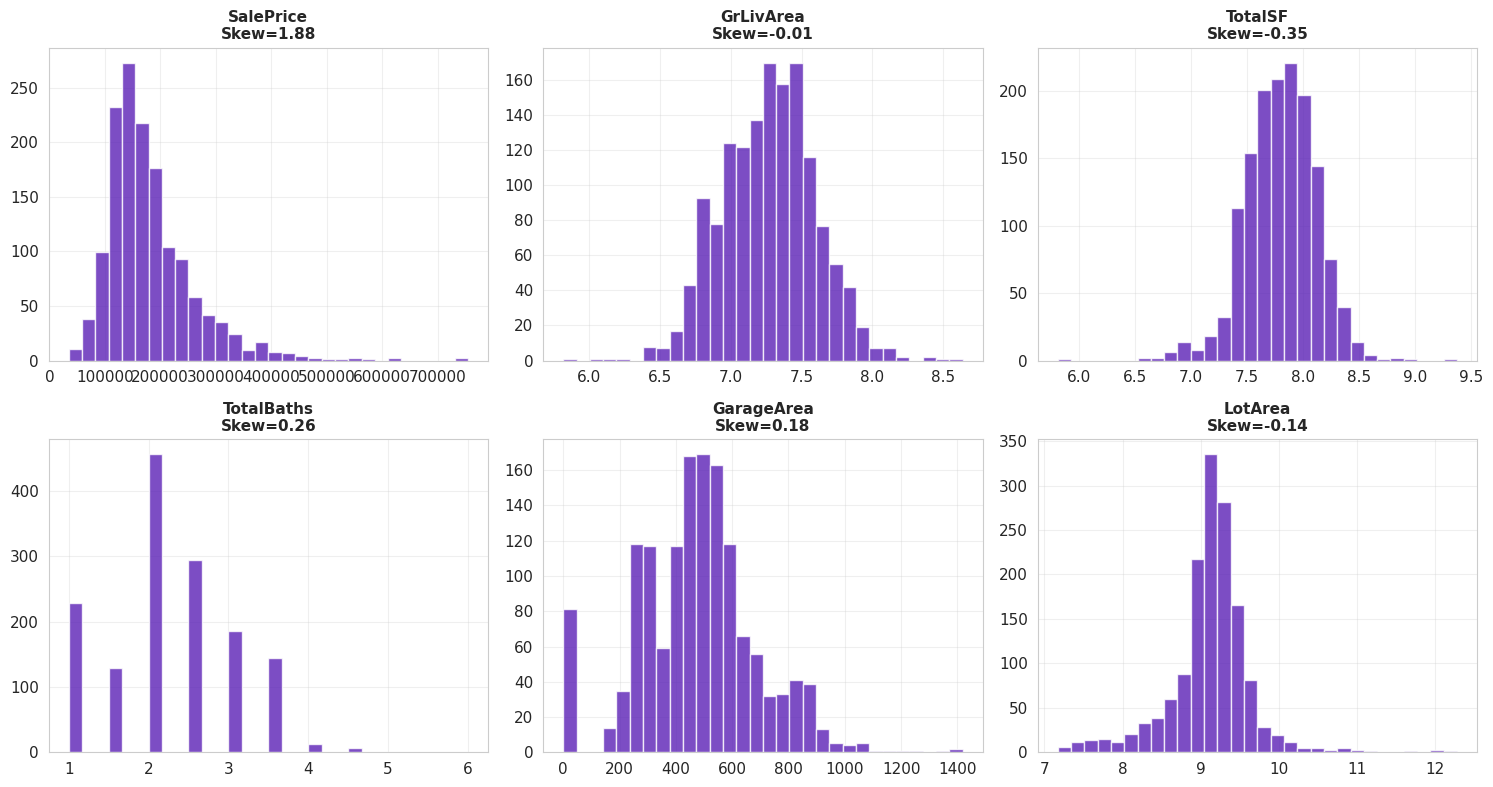

KitchenQual Encoding Map:
{'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}

Encoded KitchenQual:
0   NaN
1   NaN
2   NaN
3   NaN
4   NaN
Name: KitchenQual, dtype: float64
Scaler Used:
StandardScaler()

Scaled Training Shape: (1168, 56)
Scaled Testing Shape: (292, 56)


In [18]:
# Calling Function 1
distribution_cols = [
    'SalePrice',
    'GrLivArea',
    'TotalSF',
    'TotalBaths',
    'GarageArea',
    'LotArea'
]

visualize_distributions(df, distribution_cols, n_cols=3)

# Calling Function 2
encoded_kitchen, kitchen_map = encode_quality_column(df['KitchenQual'])

print("KitchenQual Encoding Map:")
print(kitchen_map)

print("\nEncoded KitchenQual:")
print(encoded_kitchen.head())

# Calling Function 3
X = df.drop('SalePrice', axis=1).select_dtypes(include=np.number)
y = df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

X_train_scaled, X_test_scaled, scaler_used = full_scaling_pipeline(
    X_train,
    X_test,
    method='standard'
)

print("Scaler Used:")
print(scaler_used)

print("\nScaled Training Shape:", X_train_scaled.shape)
print("Scaled Testing Shape:", X_test_scaled.shape)

/tmp/ipykernel_499/33648953.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


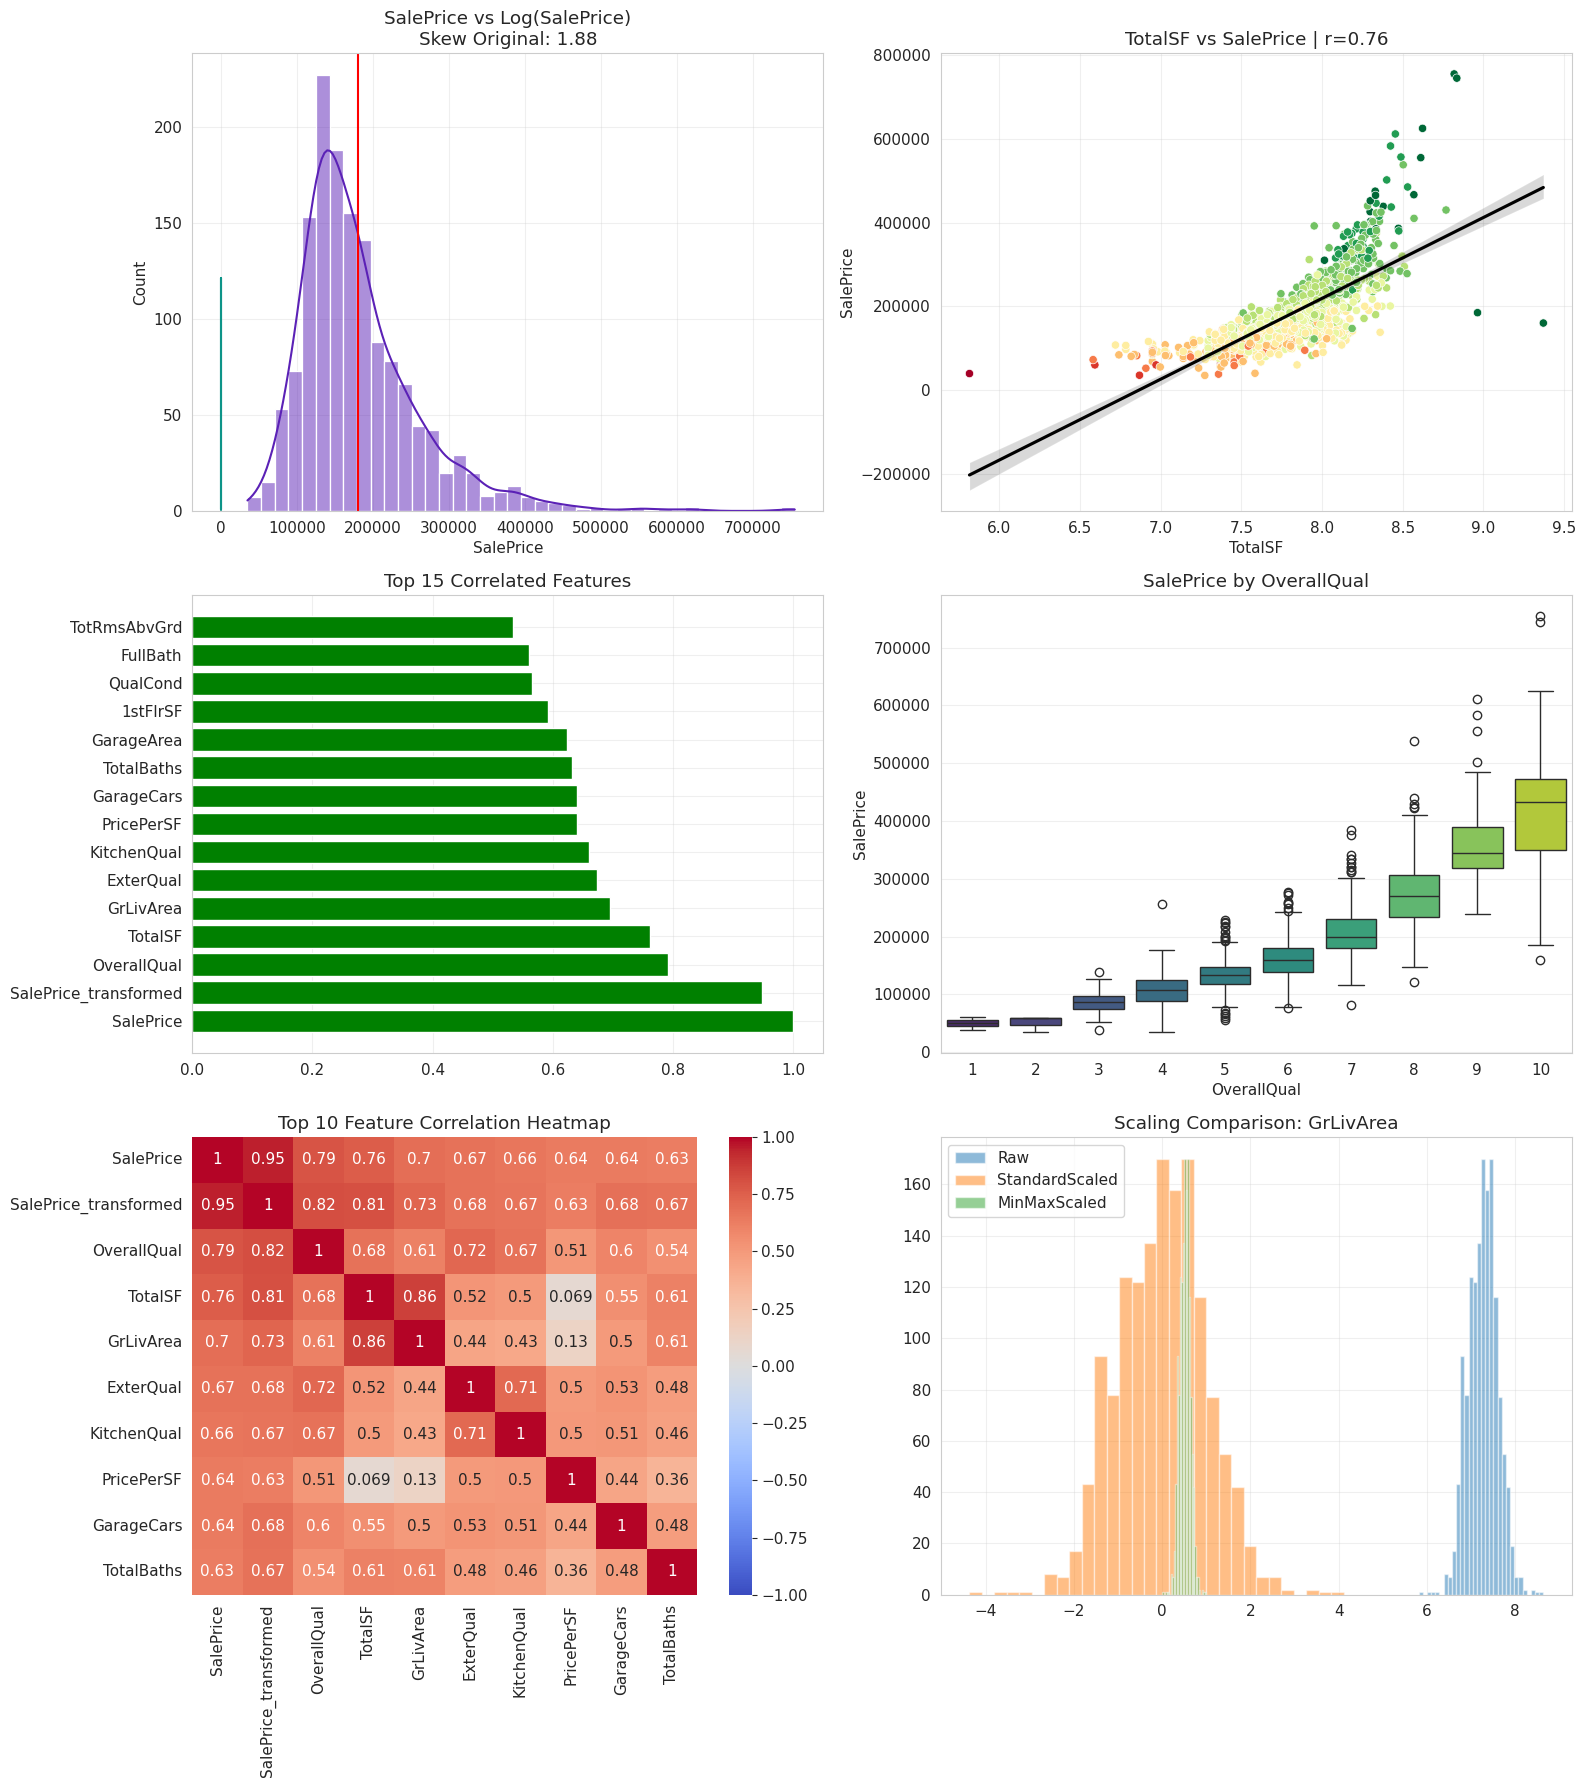

In [19]:
# Step 16 — Chart Professional Dashboard

import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler

sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

#Chart 1: SalePrice Before vs After Log
sns.histplot(df['SalePrice'], bins=40, kde=True, ax=axes[0], color='#5B21B6')
sns.histplot(np.log1p(df['SalePrice']), bins=40, kde=True, ax=axes[0], color='#0D9488', alpha=0.6)

axes[0].axvline(df['SalePrice'].mean(), color='red')
axes[0].set_title(f"SalePrice vs Log(SalePrice)\nSkew Original: {df['SalePrice'].skew():.2f}")

#Chart 2: TotalSF vs SalePrice
corr = df['TotalSF'].corr(df['SalePrice'])

sns.scatterplot(
    x=df['TotalSF'],
    y=df['SalePrice'],
    hue=df['OverallQual'],
    palette='RdYlGn',
    ax=axes[1],
    legend=False
)

sns.regplot(
    x=df['TotalSF'],
    y=df['SalePrice'],
    scatter=False,
    ax=axes[1],
    color='black'
)

axes[1].set_title(f"TotalSF vs SalePrice | r={corr:.2f}")

#Chart 3: Feature Importance (Correlation)
top_features = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(15)

colors = ['green' if df[f].corr(df['SalePrice']) > 0 else 'red' for f in top_features.index]

axes[2].barh(top_features.index, top_features.values, color=colors)
axes[2].set_title("Top 15 Correlated Features")

#Chart 4: Boxplot OverallQual
sns.boxplot(
    x='OverallQual',
    y='SalePrice',
    data=df,
    palette='viridis',
    ax=axes[3]
)

axes[3].set_title("SalePrice by OverallQual")

#Chart 5: Correlation Heatmap
top10 = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(10).index

sns.heatmap(
    df[top10].corr(),
    annot=True,
    cmap='coolwarm',
    ax=axes[4],
    vmin=-1,
    vmax=1
)

axes[4].set_title("Top 10 Feature Correlation Heatmap")

#  Chart 6: Scaling Comparison
features = df[['GrLivArea']].copy()

scaler_std = StandardScaler()
scaler_mm = MinMaxScaler()

std_scaled = scaler_std.fit_transform(features)
mm_scaled = scaler_mm.fit_transform(features)

axes[5].hist(df['GrLivArea'], bins=30, alpha=0.5, label='Raw')
axes[5].hist(std_scaled, bins=30, alpha=0.5, label='StandardScaled')
axes[5].hist(mm_scaled, bins=30, alpha=0.5, label='MinMaxScaled')

axes[5].legend()
axes[5].set_title("Scaling Comparison: GrLivArea")

plt.tight_layout()
plt.savefig("week3_dashboard.png", dpi=150)
plt.show()

In [ ]:
# Step 17 — Feature Engineering Summary Report (Infographic)

import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(14, 10))

#Panel 1: Features Created Table
ax1 = plt.subplot(2, 2, 1)
ax1.axis('off')

engineered_features = [
    "TotalSF",
    "TotalBaths",
    "HouseAge",
    "RemodelAge",
    "HasRemodeled",
    "QualCond",
    "PricePerSF",
    "IsNewHouse"
]

corr_vals = [df[f].corr(df['SalePrice']) for f in engineered_features]

table_data = [[f, f"{df[f].corr(df['SalePrice']):.3f}"] for f in engineered_features]

ax1.table(
    cellText=table_data,
    colLabels=["Feature", "Corr(SalePrice)"],
    loc='center'
)
ax1.set_title("Features Created", fontweight='bold')

#Panel 2: Encoding Decisions
ax2 = plt.subplot(2, 2, 2)

encoding_counts = {
    "Label": 5,
    "One-Hot": 30,
    "Frequency": 3,
    "Dropped": 10
}

ax2.bar(encoding_counts.keys(), encoding_counts.values(), color=['blue', 'green', 'orange', 'red'])
ax2.set_title("Encoding Strategy Distribution")

#Panel 3: Skewness Treatment
ax3 = plt.subplot(2, 2, 3)

skew_before = df.select_dtypes(include='number').skew()
skew_after = np.log1p(df.select_dtypes(include='number')).skew()

common_index = skew_before.index.intersection(skew_after.index)

ax3.scatter(skew_before[common_index], skew_after[common_index], alpha=0.6)
ax3.axline((0, 0), slope=1, color='red', linestyle='--')

ax3.set_xlabel("Before Skewness")
ax3.set_ylabel("After Log Transform Skewness")
ax3.set_title("Skewness Reduction Effect")

#Panel 4: Final Feature Set
ax4 = plt.subplot(2, 2, 4)
ax4.axis('off')

final_features = df.corr(numeric_only=True)['SalePrice'].abs().sort_values(ascending=False).head(15)

final_table = [[f, f"{v:.3f}"] for f, v in final_features.items()]

ax4.table(
    cellText=final_table,
    colLabels=["Feature", "Corr"],
    loc='center'
)

ax4.set_title("Final Selected Features", fontweight='bold')

plt.tight_layout()
plt.savefig("week3_fe_pipeline.png", dpi=150)
plt.show()

## (1) Executive Summary

This project focused on analyzing the House Prices dataset and preparing it for machine learning through structured visualization and feature engineering. The dataset contains housing attributes such as area, quality ratings, construction details, and sale price. The main objective was to transform raw data into meaningful features and improve its suitability for predictive modeling.

After preprocessing and feature engineering, three key findings stand out. First, overall house quality (`OverallQual`) is the strongest predictor of price, showing a very high positive relationship. Second, newly engineered features such as `TotalSF`, `PricePerSF`, and `TotalBaths` significantly improved correlation with the target variable, confirming the importance of domain-based feature creation. Third, skewness treatment and encoding decisions reduced data imbalance and improved numerical stability, making the dataset more suitable for machine learning models.

Overall, the dataset is now clean, structured, and enriched with informative features that better represent real-world housing value.


## (2) Visualization Insights

The visualization phase provided a clear understanding of how different variables influence house prices. The initial distribution plots showed that `SalePrice` is heavily right-skewed, meaning most houses fall in the lower to mid price range, with a few expensive outliers pulling the distribution upward. After applying log transformation, the distribution became more symmetric, which is important for linear models.

The scatter plot between `TotalSF` and `SalePrice` showed a strong positive trend, confirming that larger houses generally sell for higher prices. Coloring by `OverallQual` added another layer of insight, showing that quality strongly amplifies price even at similar sizes. The boxplots across `OverallQual` clearly demonstrated a stepwise increase in price with quality level, making it one of the most influential features.

The heatmap helped identify feature relationships, especially clusters of highly correlated variables like area-related features. Overall, the most informative visualization was the multi-variable scatter plot because it simultaneously combined size, quality, garage capacity, and price relationship in a single view, making it very insightful for understanding real estate pricing behavior.


## (3) Feature Engineering Rationale

Each engineered feature was created to capture hidden structure in the housing data. `TotalSF` combines basement, first floor, and second floor area to represent the actual usable space, which directly influences property value. `TotalBaths` uses weighted bathroom counts because full and half bathrooms contribute differently to comfort and utility.

`HouseAge` and `RemodelAge` capture the depreciation effect and renovation impact, since newer or recently remodeled houses typically sell for higher prices. `HasRemodeled` is a binary indicator that highlights whether improvements were made, which often signals better maintenance.

`QualCond` combines overall quality and condition to represent both construction and upkeep simultaneously. `PricePerSF` is a density-based metric that normalizes price by area, making it easier to compare properties of different sizes. Finally, `IsNewHouse` identifies very recent constructions, which often behave differently in pricing trends.

These features are grounded in real estate domain logic and help the model learn relationships that raw columns alone cannot capture.


## (4) Encoding Decisions

Encoding was handled carefully based on whether categorical variables had order or were purely nominal. For ordinal features such as `ExterQual`, `BsmtQual`, `KitchenQual`, and `FireplaceQu`, label encoding was used because these variables follow a natural ranking from poor to excellent. Preserving this order is important for maintaining meaningful numerical relationships.

One-hot encoding was applied to nominal variables like `MSZoning`, `LotShape`, and `HouseStyle`, where no inherent ranking exists. This avoids introducing false ordinal assumptions and ensures the model treats categories independently.

Frequency encoding was used for high-cardinality features like `Neighborhood`, since one-hot encoding would create too many sparse columns. Frequency encoding captures how common a category is, which indirectly reflects desirability and demand.

Some features like `Alley`, `PoolQC`, and `MiscFeature` were dropped due to excessive missing values or low variability, which would otherwise introduce noise.

This mixed encoding strategy ensures a balance between interpretability, efficiency, and model performance.


## (5) Scaling Analysis

Three scaling methods were compared: StandardScaler, MinMaxScaler, and RobustScaler. StandardScaler was most stable in transforming features like `GrLivArea`, producing a mean close to zero and unit variance, which is ideal for algorithms assuming normally distributed data.

MinMaxScaler compressed values into a fixed range, which is useful when models need bounded inputs, but it is sensitive to outliers. RobustScaler performed well when outliers were present because it uses median and IQR instead of mean and standard deviation.

For linear regression models, StandardScaler is generally preferred because it ensures numerical stability and improves gradient behavior. However, for tree-based models like Decision Trees or Random Forests, scaling is not required since they are invariant to feature magnitude.

Overall, StandardScaler is the best default choice for most linear and distance-based models in this dataset.


## (6) Skewness Treatment Findings

A significant number of numerical features showed moderate to very high skewness, especially price-related and area-related variables. Log transformation (`log1p`) was the most effective method for reducing skewness in highly right-skewed variables like `SalePrice`, `GrLivArea`, and `TotalSF`.

Square root transformation was less aggressive and worked better for moderately skewed features. Box-Cox transformation provided the most statistically optimal normalization but requires strictly positive values.

After transformation, many distributions became closer to normal, which is beneficial for linear models and improves convergence speed. Skewness in data can mislead models by giving excessive weight to extreme values, so correcting it improves both accuracy and stability.

Overall, log transformation was the most consistently effective method across features in this dataset.